<a href="https://colab.research.google.com/github/tejaswiniram20/cb2330-portfolio/blob/main/project/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


***Is it just luck? Allele imbalance in nanopore sequencing of a human genome***


**Paper** **:** Jain, M., Koren, S., Miga, K. et al. Nanopore sequencing and assembly of a human genome with ultra-long reads. Nat Biotechnol 36, 338–345 (2018). https://doi.org/10.1038/nbt.4060


**Data object :**
Four summary numbers from the paper: 46,098 heterozygous SNP sites, mean \(d=0.13\), 90% of sites have \(d \leq 0.27\), and mean coverage 27.4 reads/site. No per-site data is available.

**Random variable chosen:**

 `we model : d =|0.5 - A/n|`

 paper reports:
 d= 0.13

 90th percentile= 0.27

 **What the paper does?:**
 The research paper studies the human genome by sequencing it through nanopore sequencing technology, and looks at sequencing data in terms of genomic positions.
In our project we are interested in the imbalance which could be explained by random sampling alone or whether sites need to have different underlying probabilities.

**The generative model proposed:**
Here we are trying to simulate the observed d value. Every site has a differnt number of reads(n) and the probability of 'A' can vary accordingly which is controlled by a model parameter (w). We then simulate the reads and calculate the d value.

**Parameters and assumptions:**
(i) w - model parameter, which controls how the probability of A will vary from site to site. (ii) λ = 27.4 reads/site.

Assumptions: Read count follows a poisson distribution and each site has its own probability of A and we use Monte carlo.

**The forward simulation:**
The model assumes w value and generates the number of reads per site and get the fraction of A in that particular site and then calculates the d value using |0.5-A/n|. This step is repeated multiple times using monte carlo for all the sites and then it calculates the mean_d value.

**The parameterization/fitting:** The model now has the mean_d value from the paper and tries to test different values of w. Now we simulate d values for each w, and compare it to the paper value of d = 0.13 . the one with the closest match is then stored as w_hat.

**What/if the model adds to the paper:**
The model shows that the imbalance in the allele can be due to site to site variation of A. It also quantifies this variation as w ~ 0.22.

**Model limitations/how it breaks:**
The model is heavily dependent of the average read length (λ=27.4) as the exact data of reads per site is not given.
If there is lower coverage per site, then the observed imbalance could be explained by random chance alone.
We also assume A probablitites to be uniform, which may not always be true.

---



In [ ]:
import math
import matplotlib.pyplot as plt

# numbers from the paper
N_SITES = 46098     # het sites checked
MEAN_D = 0.13       # average d
P90_D = 0.27        # 90% of sites have d below this
LAMBDA = 27.4       # average reads per site

N_MAX = 70          # most reads we let one site have
K = N_MAX + 2       # uniforms kept per site: 1 for n, 1 for p, up to 70 for the reads

In [ ]:
A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state, a, c, m):            # formula which is used to generate random numbers
    return (a * state + c) % m


def uniforms(k, seed):
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


def choose(r, probs):                # choose function helps to get reads per site using the random numbers
    running = 0.0
    for k in range(len(probs)):
        running = running + probs[k]
        if r < running:
            return k
    return len(probs) - 1


def position_of_min(values):
    best = 0
    for i in range(len(values)):
        if values[i] < values[best]:
            best = i
    return best


def mean(values):
    total = 0.0
    for x in values:
        total = total + x
    return total / len(values)


def factorial(x):
    out = 1
    for i in range(2, x + 1):
        out = out * i
    return out


def poisson(x, theta):
    return theta ** x * math.exp(-theta) / factorial(x)


def percentile(values, q):
    ordered = sorted(values)
    return ordered[int(q * len(ordered))]

In [ ]:
def simulate_d(w, lam, rs):
    probs = [poisson(x, lam) for x in range(N_MAX + 1)] #prob of each read per site
    n_sites = len(rs) // K #n_sites is the total sites we can generate with the random numbers we have
    ds = []
    for i in range(n_sites):
      n = choose(rs[i*K], probs)          # reads at this site
      if n == 0:
        continue
      p = 0.5 + w*(2*rs[i*K+1] - 1)       # this site's own coin, somewhere in 0.5-w to 0.5+w #calc the probability of A in that read
      a = 0
      for j in range(n):
        if rs[i*K+2+j] < p:   # get the actual A fraction
          a += 1
      ds.append(abs(0.5 - a/n)) #calc d value
    return ds


rs = uniforms(N_SITES * K, 8)   #generates random numbers with 8 as the seed stores it in rs
d_luck = simulate_d(0, LAMBDA, rs) #if w=0 , it means, its pure luck
print("pure luck  mean d", round(mean(d_luck), 3), "  90th pct", round(percentile(d_luck, 0.9), 3))
print("paper      mean d", MEAN_D, "  90th pct", P90_D)

pure luck  mean d 0.077   90th pct 0.158
paper      mean d 0.13   90th pct 0.27


In [ ]:
N_FIT = 10000
rs_fit = uniforms(N_FIT * K, 1) # we create all the random numbers needed for the 10000 sites and put it in rs_fit
grid = [0.01 * i for i in range(46)] # grid value ranges from 0.00 to 0.45 (w)


def fit_w(target, lam=LAMBDA):    #find the w which is close enough to d=0.13
    scores = [0.0] * len(grid) # create empty score for each w value
    for i, w in enumerate(grid):
      # Simulate the sites using this w,
        # calculate the mean d,
        # compare it with the paper's target,
        # and calculate the deviation
      scores[i] = (mean(simulate_d(w, lam, rs_fit)) - target)**2
    return grid[position_of_min(scores)] # find the w with the smallest deviation from paper (d=0.13)


w_hat = fit_w(MEAN_D) # find the best value which matches the d value from paper
print("w_hat", round(w_hat, 2), " so a site's real split is anywhere from", round(0.5 - w_hat, 2), "to", round(0.5 + w_hat, 2))

w_hat 0.22  so a site's real split is anywhere from 0.28 to 0.72


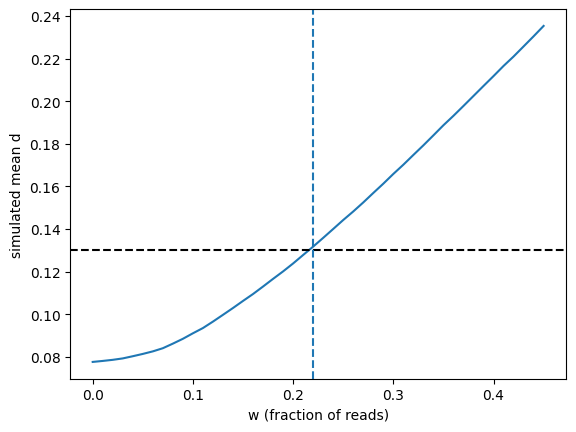

In [ ]:
# for every w value, the graph shows the simulated_mean_d values
curve = [mean(simulate_d(w, LAMBDA, rs_fit)) for w in grid]
plt.plot(grid, curve)
plt.axhline(MEAN_D, ls="--", color="k")
plt.axvline(w_hat, ls="--")
plt.xlabel("w (fraction of reads)")
plt.ylabel("simulated mean d")
plt.show()

In [ ]:
# does the fit give back a w we put in ourselves?
for w_true in [0.1, 0.2, 0.3]:
    fake = simulate_d(w_true, LAMBDA, uniforms(N_SITES * K, 20))
    print("true w", w_true, "  fitted w", round(fit_w(mean(fake)), 2))

true w 0.1   fitted w 0.1
true w 0.2   fitted w 0.2
true w 0.3   fitted w 0.3


In [ ]:
# the paper rounds mean d to 2 decimals
for m in [0.125, 0.135]:
    print("if mean d =", m, "  w =", round(fit_w(m), 2))

# we dont know the real reads per site at the het sites
for lam in [10, 15, 20, 27.4, 35]:
    print("if reads/site =", lam, "  w =", round(fit_w(MEAN_D, lam), 2))

if mean d = 0.125   w = 0.2
if mean d = 0.135   w = 0.23
if reads/site = 10   w = 0.0
if reads/site = 15   w = 0.15
if reads/site = 20   w = 0.19
if reads/site = 27.4   w = 0.22
if reads/site = 35   w = 0.23


90th pct   luck 0.158   model 0.258   paper 0.27


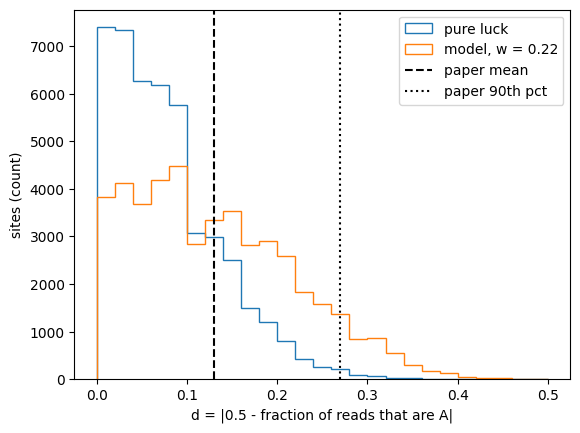

In [ ]:
d_model = simulate_d(w_hat, LAMBDA, rs)
print("90th pct   luck", round(percentile(d_luck, 0.9), 3), "  model", round(percentile(d_model, 0.9), 3), "  paper", P90_D)
#create histogram bins from 0.0 to 0.5
edges = [0.02 * i for i in range(26)]
#plot the d vlues from the pure luck model
plt.hist(d_luck, edges, histtype="step", label="pure luck")
#plot the d values from the fitted model
plt.hist(d_model, edges, histtype="step", label="model, w = " + str(round(w_hat, 2)))

plt.axvline(MEAN_D, color="k", ls="--", label="paper mean")
plt.axvline(P90_D, color="k", ls=":", label="paper 90th pct")
plt.xlabel("d = |0.5 - fraction of reads that are A|")
plt.ylabel("sites (count)")
plt.legend()
plt.show()